In [3]:
import pandas as pd
import numpy as np
from ctgan import CTGAN

X = pd.read_csv('../data/X_processed.csv')
y = pd.read_csv('../data/y_processed.csv')

print("X shape:", X.shape)
print("Class distribution:\n", y['Churn'].value_counts())

X shape: (40034, 11)
Class distribution:
 Churn
1    29698
0    10336
Name: count, dtype: int64


In [4]:
y_fixed = y.copy()
y_fixed['Churn'] = y_fixed['Churn'].map({1: 0, 0: 1})

print("Fixed class distribution:\n", y_fixed['Churn'].value_counts())

# Combine X and y for easier handling
df_combined = X.copy()
df_combined['Churn'] = y_fixed['Churn'].values

print("\nCombined shape:", df_combined.shape)

Fixed class distribution:
 Churn
0    29698
1    10336
Name: count, dtype: int64

Combined shape: (40034, 12)


In [3]:
# Separate minority class (churned = 1, now 10,336 rows)
minority_df = df_combined[df_combined['Churn'] == 1].copy().reset_index(drop=True)
train_df = minority_df.drop(columns=['Churn'])

print(f"Training CTGAN on {len(train_df)} minority samples...")
print(f"Columns: {train_df.columns.tolist()}")

# All columns are float64, so discrete_columns=[]
ctgan = CTGAN(epochs=200, verbose=True)
ctgan.fit(train_df, discrete_columns=[])

print("\n✓ CTGAN training complete")

Training CTGAN on 10336 minority samples...
Columns: ['Age', 'Gender', 'Location', 'GameGenre', 'PlayTimeHours', 'InGamePurchases', 'GameDifficulty', 'SessionsPerWeek', 'AvgSessionDurationMinutes', 'PlayerLevel', 'AchievementsUnlocked']


Gen. (-03.23) | Discrim. (+00.14): 100%|██████████| 200/200 [01:45<00:00,  1.90it/s]


✓ CTGAN training complete


In [4]:
# Always test with small sample first
test = ctgan.sample(5)
print("Test sample (5 rows):")
print(test)
print("\nTest passed ✓ — proceeding to full generation")

Test sample (5 rows):
        Age    Gender  Location  GameGenre  PlayTimeHours  InGamePurchases  \
0 -1.080280 -1.207846  0.250700  -0.011912      -0.231117         1.977217   
1 -0.987969  0.821954 -1.391356  -1.447553      -1.555550         2.006146   
2 -0.460133  0.808075 -1.407902  -0.012518      -1.512421        -0.497411   
3  1.642655  0.811765 -0.599402   1.398579       0.299728        -0.496849   
4 -0.290054  0.813731 -0.572859  -0.708979       1.678465         1.978477   

   GameDifficulty  SessionsPerWeek  AvgSessionDurationMinutes  PlayerLevel  \
0        0.260343         0.401752                   0.959251    -1.103938   
1       -0.915047         0.788756                   0.052823     1.698814   
2        1.383524         1.639720                   0.934009    -1.335788   
3        0.244328        -0.092294                   0.550666    -0.086295   
4        0.223587         0.928402                   1.206592     0.142535   

   AchievementsUnlocked  
0             

In [5]:
n_majority = int((df_combined['Churn'] == 0).sum())  # 29,698
n_minority = int((df_combined['Churn'] == 1).sum())  # 10,336
n_to_generate = n_majority - n_minority               # ~19,362

print(f"Majority (active):  {n_majority}")
print(f"Minority (churned): {n_minority}")
print(f"Need to generate:   {n_to_generate}")

# Generate in batches of 500 to stay stable
all_batches = []
batch_size = 500
generated = 0

while generated < n_to_generate:
    chunk = min(batch_size, n_to_generate - generated)
    batch = ctgan.sample(chunk)
    all_batches.append(batch)
    generated += len(batch)
    print(f"✓ {generated} / {n_to_generate}")

synthetic = pd.concat(all_batches, ignore_index=True)
synthetic['Churn'] = 1

print(f"\n✓ Synthetic data shape: {synthetic.shape}")

Majority (active):  29698
Minority (churned): 10336
Need to generate:   19362
✓ 500 / 19362
✓ 1000 / 19362
✓ 1500 / 19362
✓ 2000 / 19362
✓ 2500 / 19362
✓ 3000 / 19362
✓ 3500 / 19362
✓ 4000 / 19362
✓ 4500 / 19362
✓ 5000 / 19362
✓ 5500 / 19362
✓ 6000 / 19362
✓ 6500 / 19362
✓ 7000 / 19362
✓ 7500 / 19362
✓ 8000 / 19362
✓ 8500 / 19362
✓ 9000 / 19362
✓ 9500 / 19362
✓ 10000 / 19362
✓ 10500 / 19362
✓ 11000 / 19362
✓ 11500 / 19362
✓ 12000 / 19362
✓ 12500 / 19362
✓ 13000 / 19362
✓ 13500 / 19362
✓ 14000 / 19362
✓ 14500 / 19362
✓ 15000 / 19362
✓ 15500 / 19362
✓ 16000 / 19362
✓ 16500 / 19362
✓ 17000 / 19362
✓ 17500 / 19362
✓ 18000 / 19362
✓ 18500 / 19362
✓ 19000 / 19362
✓ 19362 / 19362

✓ Synthetic data shape: (19362, 12)


In [6]:
balanced_df = pd.concat([df_combined, synthetic], ignore_index=True)

print("Final class distribution:")
print(balanced_df['Churn'].value_counts())
print(f"\nTotal rows: {len(balanced_df)}")

Final class distribution:
Churn
0    29698
1    29698
Name: count, dtype: int64

Total rows: 59396


In [7]:
X_balanced = balanced_df.drop(columns=['Churn'])
y_balanced = balanced_df[['Churn']]

X_balanced.to_csv('../data/X_balanced.csv', index=False)
y_balanced.to_csv('../data/y_balanced.csv', index=False)

print("✓ Saved X_balanced.csv —", X_balanced.shape)
print("✓ Saved y_balanced.csv —", y_balanced.shape)

✓ Saved X_balanced.csv — (59396, 11)
✓ Saved y_balanced.csv — (59396, 1)


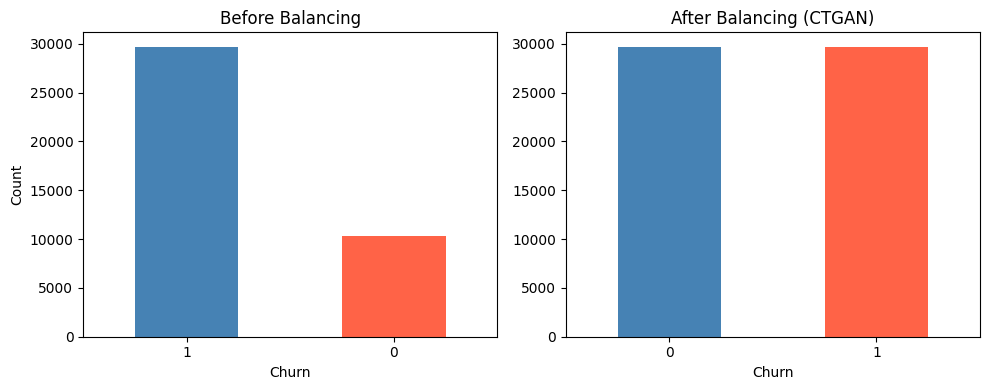

✓ Chart saved to reports/class_balance.png


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before
y['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'])
axes[0].set_title('Before Balancing')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# After
balanced_df['Churn'].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'])
axes[1].set_title('After Balancing (CTGAN)')
axes[1].set_xlabel('Churn')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../reports/class_balance.png', dpi=150)
plt.show()
print("✓ Chart saved to reports/class_balance.png")